# Use distributions

A {class}`~liesel.model.Dist` connects a distribution constructor to its inputs.
It evaluates the resulting distribution at a variable's value. Array shape and
statistical role determine how that contribution enters the model.

## Choose the event shape

In [1]:
import jax
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl
from liesel.distributions import GaussianCopula

In [2]:
values = jnp.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]])

components = lsl.Var.new_obs(
    values,
    dist=lsl.Dist(tfd.Normal, loc=jnp.zeros(2), scale=1.0),
    name="components",
).update()

vectors = lsl.Var.new_obs(
    values,
    dist=lsl.Dist(tfd.MultivariateNormalDiag, loc=jnp.zeros(2), scale_diag=jnp.ones(2)),
    name="vectors",
).update()

In [3]:
(components.log_prob.shape, vectors.log_prob.shape)

((3, 2), (3,))

The shapes are `(3, 2)` and `(3,)`. The first distribution has a batch of
two scalar normals; the second treats each two-element vector as one event.
Both describe independent normal components here, but group their densities
differently. Decide whether an observation for your analysis is a component
or a whole vector before computing pointwise scores.

`per_obs=True` preserves the distribution's log-probability output. It does
not promise one scalar per original data row. `per_obs=False` sums that
output to a scalar; model totals reduce density contributions either way.
See {doc}`optimizer-loss-scaling` before using reduced factors in minibatch fits.

## Define a distribution

Implement the log density of a Laplace distribution with location `loc` and
positive scale `scale`. Its density is proportional to
`exp(-abs(value - loc) / scale)`. Unlike a normal density, its log density
uses absolute rather than squared residuals.

In [4]:
class Laplace(tfd.Distribution):
    def __init__(self, loc, scale):
        self.loc = jnp.asarray(loc, dtype=jnp.float32)
        self.scale = jnp.asarray(scale, dtype=jnp.float32)
        super().__init__(
            dtype=jnp.float32,
            reparameterization_type=tfd.FULLY_REPARAMETERIZED,
            validate_args=False,
            allow_nan_stats=True,
            parameters={"loc": loc, "scale": scale},
            name="Laplace",
        )

    def _batch_shape(self):
        return jnp.broadcast_shapes(self.loc.shape, self.scale.shape)

    def _event_shape(self):
        return ()

    def _log_prob(self, value):
        return -jnp.log(2.0 * self.scale) - jnp.abs(value - self.loc) / self.scale

    def _sample_n(self, n, seed=None):
        noise = jax.random.laplace(
            seed, (n,) + tuple(self.batch_shape), dtype=self.dtype
        )
        return self.loc + self.scale * noise

`_log_prob` includes the normalizing term, which matters when estimating scale.
TFP exposes it through the public `log_prob` method. Each event is scalar;
location and scale can broadcast over batch dimensions. `_sample_n` supplies
forward simulation, and the constructor records its inputs for copying.
The example uses float32 values and assumes positive scale.

Connect the custom class just like a built-in distribution:

In [5]:
mu = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.5),
    name="mu",
)

scale = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.LogNormal, loc=0.0, scale=0.5),
    name="scale",
)

response = lsl.Var.new_obs(
    jnp.array([0.8, 1.2, 1.4]),
    dist=lsl.Dist(Laplace, loc=mu, scale=scale),
    name="response",
)
custom_model = lsl.Model(response)

Inspect the graph and evaluate the likelihood at two scales:

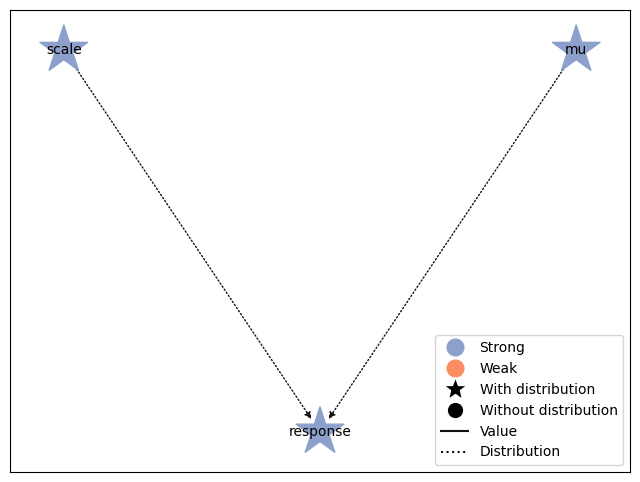

In [6]:
custom_model.plot(width=8, height=6)

In [7]:
round(float(custom_model.log_lik), 3)

-5.479

In [8]:
scale.value = 2.0

In [9]:
round(float(custom_model.log_lik), 3)

-5.859

Changing {attr}`scale.value <liesel.model.Var.value>` recomputes the likelihood. Its proper log-normal prior
expresses the positive constraint; direct assignments must still respect it.
No Liesel registration is needed. {class}`Dist <liesel.model.Dist>` also accepts a factory returning a
JAX-compatible TFP distribution.

TFP already provides `tfd.Laplace`; this small reimplementation shows where to
put a density of your own. It implements log-density evaluation and sampling,
not the full distribution API: for example, a probability integral transform
would also need a CDF. Use an explicit variable bijection for scale, as in
{doc}`model-transformations`; automatic parameter bijections need additional
TFP parameter metadata.

## Use a weak factor

A weak variable can carry a density too. For example, a copula factor evaluates
a joint dependence density on calculated marginal probability transforms:

In [10]:
margin_a = lsl.Var.new_obs(
    jnp.array([-0.5, 0.2, 0.8]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="a",
)

margin_b = lsl.Var.new_obs(
    jnp.array([-0.2, 0.3, 0.4]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="b",
)

pit_a = lsl.PIT(margin_a, name="pit_a").update()
pit_b = lsl.PIT(margin_b, name="pit_b").update()

copula = lsl.Var.new_calc(
    lambda a, b: jnp.stack([a, b], axis=-1),
    pit_a,
    pit_b,
    dist=lsl.Dist(GaussianCopula, dependence=0.3),
    name="copula",
)

copula.observed = True
copula_model = lsl.Model(copula)

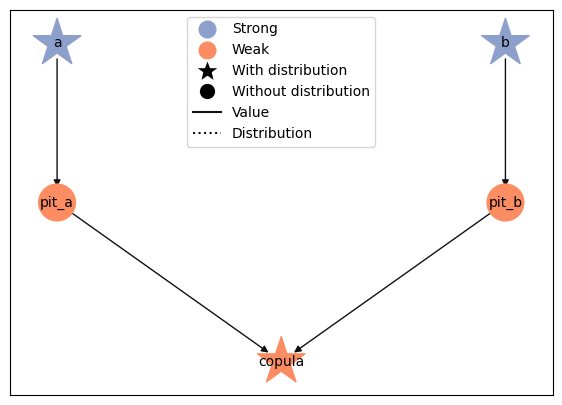

In [11]:
copula_model.plot(width=7, height=5)

In [12]:
round(float(copula_model.log_lik), 3)

-5.884

The likelihood includes the two marginal factors and the weak copula factor.
Marking the latter observed classifies its density as likelihood. Attaching a
density to a calculated value does not automatically supply a transformation
Jacobian; this example uses the copula factorization. Use
{doc}`model-transformations` for parameter transformations.

## Get pointwise densities

Using `model` and posterior `samples` from
{doc}`tutorials/notebooks/12-model-predictions`:

In [13]:
# Python cell fragment: imports are visible in each guide.
x_data = jnp.linspace(-1.0, 1.0, 120)
true_mean = 1.0 + 2.0 * x_data
true_scale = jnp.exp(-0.4 + 0.7 * x_data)
y_data = true_mean + true_scale * jax.random.normal(jax.random.key(8), (120,))

beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.5),
    name="beta",
)
gamma = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="gamma",
)
x = lsl.Var.new_obs(x_data, name="x")
mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)
log_sigma = lsl.Var.new_calc(
    lambda x, g: g[0] + g[1] * x,
    x,
    gamma,
    name="log_sigma",
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")
y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y)

for parameter in model.parameters.values():
    parameter.inference = gs.MCMCSpec(
        gs.NUTSKernel,
        kernel_group="regression",
        jitter_dist=tfd.Normal(loc=0.0, scale=0.1),
    )
results = gs.LieselMCMC(model).run_for_epochs(
    seed=31,
    num_chains=4,
    adaptation=500,
    posterior=500,
    show_progress=False,
)
samples = results.get_posterior_samples()


liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [14]:
pointwise = lsl.log_prob_pointwise(model.observed, samples)
response_key = model.vars["y"].dist_node.name

In [15]:
pointwise[response_key].shape

(4, 500, 120)

The shape is `(4, 500, 120)`. Keys name distribution nodes, not variables.
Observed variables without distributions are skipped. Keep `per_obs=True`
for these factors. For multivariate or multiple-factor models, choose the
predictive unit deliberately: separate arrays are not automatically a valid
per-observation sum. See {func}`~liesel.goose.loo` for predictive assessment.

The standard likelihood/prior decomposition requires the distribution factors
to be classified appropriately. Custom model-total nodes or other objectives
may also need a custom optimizer loss; see {doc}`optimizer-loss-scaling`.